# Considerations


There a notebook in colab due it cant be saved in kaggle.

**This notebook [Cosumer Behavioral Analysis + DeepSeekR1 ](https://colab.research.google.com/drive/1lxfnj51T5AB2ApjA-qm1W8-tC7gfQKrG?usp=drive_link#scrollTo=UxK5rj3GQLQt)**

**Vist [GitHub Repo](https://github.com/Abdelrahman-Kanakri/Data-Science-and-AI/tree/Projects/Smart%20Recycler)** 


# Importing required Libraries

In [22]:
# General Purpose Libraries
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

# Image Processing Libraries
from PIL import Image
import cv2
from glob import glob
from IPython.display import display

# Machine Learning Libraries
# TensorFlow and Keras
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input
from keras.models import Sequential, Model
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
    Rescaling
)
from keras.callbacks import EarlyStopping
from keras.applications.vgg16 import VGG16
from keras.utils import image_dataset_from_directory
from keras import Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy


import warnings
warnings.filterwarnings("ignore")

# Data Curation

## Data Gathering & Data Profiling

In [2]:
categories = os.listdir("/kaggle/input/recyclable-and-household-waste-classification/images/images")
path = "/kaggle/input/recyclable-and-household-waste-classification/images/images"
categories

['plastic_soda_bottles',
 'aerosol_cans',
 'steel_food_cans',
 'disposable_plastic_cutlery',
 'cardboard_boxes',
 'glass_beverage_bottles',
 'plastic_cup_lids',
 'plastic_straws',
 'plastic_shopping_bags',
 'styrofoam_cups',
 'cardboard_packaging',
 'glass_food_jars',
 'styrofoam_food_containers',
 'eggshells',
 'aluminum_food_cans',
 'coffee_grounds',
 'plastic_food_containers',
 'food_waste',
 'magazines',
 'shoes',
 'clothing',
 'aluminum_soda_cans',
 'plastic_detergent_bottles',
 'newspaper',
 'tea_bags',
 'office_paper',
 'plastic_water_bottles',
 'paper_cups',
 'glass_cosmetic_containers',
 'plastic_trash_bags']

## Data Wrangling

In [4]:
# we need to combine all the subdirectories together to calculate the number of files for each category
def dir_info(path):
    """
    The function accesses each directory and subdirectory to add it into a DataFrame containing:
    - Main directory name
    - Total number of files in all subdirectories
    """
    # Initialize an empty list to store data
    data = []

    for main_folder in os.listdir(path):
        main_folder_path = os.path.join(path, main_folder)

        if os.path.isdir(main_folder_path):  
            total_files = 0  # Initialize counter for total files
    
            for sub_folder in os.listdir(main_folder_path):  
                sub_folder_path = os.path.join(main_folder_path, sub_folder)

                if os.path.isdir(sub_folder_path):
                    files = [f for f in os.listdir(sub_folder_path) if os.path.isfile(os.path.join(sub_folder_path, f))]
                    num_files = len(files)
                    total_files += num_files  # Add to total count

            # Append the information as a dictionary
            data.append({
                "Main Directory": main_folder,
                "Total Number of Files": total_files
            })

    # Convert the list of dictionaries into a DataFrame
    Category = pd.DataFrame(data)
    return Category

# Example usage:
path = "/kaggle/input/recyclable-and-household-waste-classification/images/images"
cats = dir_info(path)
print(cats)

                Main Directory  Total Number of Files
0         plastic_soda_bottles                    500
1                 aerosol_cans                    500
2              steel_food_cans                    500
3   disposable_plastic_cutlery                    500
4              cardboard_boxes                    500
5       glass_beverage_bottles                    500
6             plastic_cup_lids                    500
7               plastic_straws                    500
8        plastic_shopping_bags                    500
9               styrofoam_cups                    500
10         cardboard_packaging                    500
11             glass_food_jars                    500
12   styrofoam_food_containers                    500
13                   eggshells                    500
14          aluminum_food_cans                    500
15              coffee_grounds                    500
16     plastic_food_containers                    500
17                  food_was

In [5]:
images = glob(os.path.join(path, '**/*.png'), recursive=True)
print(f"Total images found: {len(images)}")

Total images found: 15000


In [6]:
def plot(folder):
    for image_path in folder:
        print(f"Opening image: {image_path}")
        # Open the image using PIL
        img = Image.open(image_path)

        # Convert image to RGB if it's in a different mode (e.g., RGBA)
        img = img.convert("RGB")
        
        # Plot the image using matplotlib
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.axis('off')  # Hide axes for better visualization
        plt.show()
#plot(images)

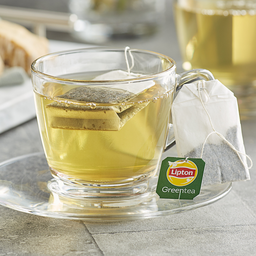

In [7]:
# Displays a sample

# Path to the image
image_path = images[12000]

# Open the image using PIL
img_pil = Image.open(image_path)


# Display the image
display(img_pil)

## Defining the data

In [8]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

In [9]:
# Define the training dataset
train = image_dataset_from_directory(
    path,
    labels='inferred',  # Automatically infers labels from subdirectory names
    label_mode='categorical',  # Return labels as one-hot encoded vectors
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,  # 20% for validation
    subset='training',
    seed=42
)

# Define the validation dataset
validation = image_dataset_from_directory(
    path,
    labels='inferred',  # Automatically infers labels from subdirectory names
    label_mode='categorical',  # Return labels as one-hot encoded vectors
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,  # 20% for validation
    subset='validation',
    seed=42
)

Found 15000 files belonging to 30 classes.
Using 12000 files for training.
Found 15000 files belonging to 30 classes.
Using 3000 files for validation.


In [10]:
classes = train.class_names
classes

['aerosol_cans',
 'aluminum_food_cans',
 'aluminum_soda_cans',
 'cardboard_boxes',
 'cardboard_packaging',
 'clothing',
 'coffee_grounds',
 'disposable_plastic_cutlery',
 'eggshells',
 'food_waste',
 'glass_beverage_bottles',
 'glass_cosmetic_containers',
 'glass_food_jars',
 'magazines',
 'newspaper',
 'office_paper',
 'paper_cups',
 'plastic_cup_lids',
 'plastic_detergent_bottles',
 'plastic_food_containers',
 'plastic_shopping_bags',
 'plastic_soda_bottles',
 'plastic_straws',
 'plastic_trash_bags',
 'plastic_water_bottles',
 'shoes',
 'steel_food_cans',
 'styrofoam_cups',
 'styrofoam_food_containers',
 'tea_bags']

In [11]:
for images, labels in train.take(1):
    print("Image batch shape: ", images.shape)
    print("Label batch shape: ", labels.shape)
    print("Labels: ", labels.numpy())

Image batch shape:  (32, 224, 224, 3)
Label batch shape:  (32, 30)
Labels:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

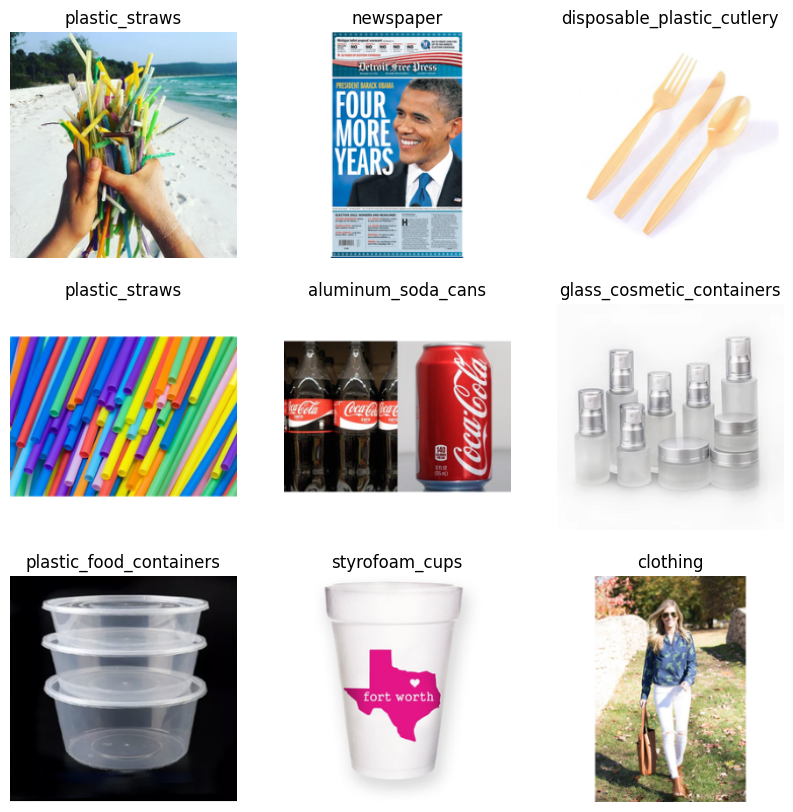

In [12]:
# Verify the dataset structure and plot some examples
plt.figure(figsize=(10, 10))
for images, labels in train.take(2):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = tf.argmax(labels[i]).numpy()  # Get the index of the highest value (class)
        plt.title(classes[label_index])
        plt.axis("off")

plt.show()

# Model Devlopment

## Parameter Definition & Data Augmentation Pipeline Preperation

In [13]:
# Automatically tune the performance by adjusting the buffer size for optimal data prefetching
AUTOTUNE = tf.data.experimental.AUTOTUNE

# Prefetch the data to improve performance by overlapping data preprocessing and model training
# This helps reduce the idle time during training
train = train.prefetch(buffer_size=AUTOTUNE)

# Preprocessing function for the input image data, specific to the ResNet50 model
# It ensures the input data is in the correct format for ResNet50 (e.g., scaling pixel values)
preprocess_input = tf.keras.applications.resnet50.preprocess_input


# Define the path to the images folder within the Kaggle environment
# This path will be used to load the dataset from a directory
path = "/kaggle/input/recyclable-and-household-waste-classification/images/images"

# Define the batch size for loading data
# Batching helps in efficiently training the model by processing images in batches rather than individually
BATCH_SIZE = 32

# Define the target image size for resizing images before feeding them into the model
# This ensures all images have consistent dimensions for training (224x224 is the standard for many models like ResNet)
IMG_SIZE = (224, 224)

# Dropout rate specifies the fraction of input units to drop during training.
# A rate of 0.5 means 50% of the units will be randomly set to zero during training to prevent overfitting.
dropout_rate = 0.5

# Learning rate defines the step size used during the optimization process.
# A learning rate of 0.001 is commonly used for models like ResNet and helps the model converge slowly but steadily.
learning_rate = 0.001

# Define the input shape for the model, combining the image size and the number of color channels
input_shape = IMG_SIZE + (3,)


## RESNET50

In [14]:
# Define the input image shape with (3,) meaning RGB structure of the image.
IMG_SHAPE = IMG_SIZE + (3,)

# Loading the ResNet50 model without the top(dense layer), including the imagenet weights
base_model = ResNet50(input_shape=IMG_SHAPE,include_top=False, weights='imagenet')

# Trainable model to fine tune the layers
base_model.trainable = True  # Enable fine-tuning

# Freeze layers up to the 150th layer leaving the rest to be trained.
fine_tune_at = 150
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
# Check Model Layers without the Top (Dense Layer)

no_layers = len(base_model.layers)
print("Number of layers without the top:", no_layers)

Number of layers without the top: 175


In [19]:
# Number Of Taregt Classes
print("Number of classes: ",len(classes))

Number of classes:  30


In [23]:
# Create the Sequential model in order to save it on .h5 format
model = Sequential()

# Data Augmentation Layers
model.add(RandomFlip('horizontal', input_shape=input_shape))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomContrast(0.2))

# Add the base model to Sequential
model.add(base_model)

# Add feature extraction parts (pooling, dropout, and output layers) 
model.add(GlobalAveragePooling2D())
model.add(Dropout(dropout_rate)) # dropout_rate as we mentioned above
model.add(Dense(units=len(classes), kernel_regularizer=l2(0.01), activation='softmax'))

In [24]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=learning_rate),
              loss=CategoricalCrossentropy(from_logits=False),  # Set from_logits to False for softmax
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_1 (RandomRotation)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_1 (RandomZoom)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast_1 (RandomContrast)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │          61,470 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,649,182 (90.21 MB)

 Trainable params: 10,051,614 (38.34 MB)

 Non-trainable params: 13,597,568 (51.87 MB)

In [ ]:
history = model.fit(train ,epochs=15, validation_data = validation, verbose=1,

     )

 # Model Testing

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in validation.take(1):
    # Predict the labels for the batch of images
    predictions = model.predict(images)
    predicted_labels = tf.argmax(predictions, axis=1)
    
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        true_label_index = tf.argmax(labels[i]).numpy()  # Get the index of the highest value (true class)
        predicted_label_index = predicted_labels[i].numpy()  # Get the index of the highest value (predicted class)
        
        true_label_name = classes[true_label_index]
        predicted_label_name = classes[predicted_label_index]
        
        plt.title(f'True: {true_label_name}\nPred: {predicted_label_name}')
        plt.axis("off")

plt.show()

# Save the model

In [ ]:
model.save("resNet_89.keras")

# Load the model with custom objects
loaded_model = tf.keras.models.load_model("resNet_89.keras")

# Model Deployment

In [ ]:
image_path = ""
image = Image.open(image_path)

# Define the new size (width, height)
new_size = (256, 256)  # Example: Resize to 256x256 pixels

# Resize the image
resized_image = image.resize(new_size)


# Save or display the resized image
resized_image.save("resized_image.png")  # Save the resized image
resized_image.show()  # Display the resized imag

In [ ]:

image_path = "/kaggle/input/screenshot/Screenshot 2025-02-11 181352.png"  # Replace with the path to your image
img = image.load_img(image_path, target_size=(256, 256))  # Resize to (256, 256)

# Convert the image to a numpy array
img_array = image.img_to_array(img)

# Add a batch dimension (since the model expects a batch of images)
img_array = np.expand_dims(img_array, axis=0)

# Preprocess the image (normalize pixel values)
img_array = preprocess_input(img_array)

# Make the prediction
predictions = model.predict(img_array)

# Interpret the prediction
predicted_class = np.argmax(predictions, axis=1)  # Get the index of the highest probability
predicted_probability = np.max(predictions, axis=1)  # Get the highest probability

In [ ]:
predicted_class

In [ ]:
for i,class_ in enumerate(classes):
    print(f"{i}: {class_}")